# Feature Selection

### Common Imports

In [1]:
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier

### Load Data

In [2]:
df = pd.read_parquet(
    open("../../../data/2021/processed/natality_2021_cleaned.parquet", "rb")
)

### Feature Exclusion

We'll remove features that are recorded after the birth of the child, such as APGAR scores and details about the particulars of the birth and recovery period.

In [3]:
unrelated_features = [
    "marital_status",
    "cigarette_recode",
    "final_route_and_method_of_delivery",
    "five_minute_apgar_score",
    "five_minute_apgar_recode",
    "ten_minute_apgar_score",
    "ten_minute_apgar_score_recode",
    "plurality_recode",
    "set_order_recode",
    "last_normal_menses_month",
    "last_normal_menses_year",
    "obstetric_estimate_edited",
    "assisted_ventilation_immediate",
    "assisted_ventilation_after_6_hours",
    "admission_to_nicu",
    "surfactant",
    "antibiotics_for_newborn",
    "seizures",
    "no_abnormal_conditions_reported",
    "infant_transferred",
    "infant_living_at_time_of_report",
    "infant_breastfed_at_discharge",
    "month_prenatal_care_started",
    "no_maternal_comorbidity_reported",
    "perineal_laceration",
    "ruptured_uterus",
    "total_birth_order_recode",
    "unplanned_hysterectomy",
    "maternal_transfusion",
    "mother_transferred",
    "admit_to_intensive_care",
    "live_birth_order_recode",
]

df_filtered = df.drop(unrelated_features, axis="columns")

Next we'll remove some categorical duplicates of numeric columns.

In [4]:
num_feature_recodes = [
    "facility_recode",
    "mothers_age_recode_14",
    "mothers_age_recode_9",
    "mothers_race_recode_31",
    "mothers_race_recode_6",
    "mothers_hispanic_origin_recode",
    "fathers_age_recode_11",
    "fathers_race_recode_31",
    "fathers_race_recode_6",
    "fathers_hispanic_origin_recode",
    "interval_since_last_live-birth_recode_11",
    "interval_since_last_other_pregnancy_recode_11",
    "interval_since_last_pregnancy_recode_11",
    "BMI_recode",
    "cigarettes_before_pregnancy_recode",
    "cigarettes_first_trimester_recode",
    "cigarettes_second_trimester_recode",
    "cigarettes_third_trimester_recode",
    "combined_gestation_recode_10",
    "combined_gestation_recode_3",
    "obstetric_estimate_recode_10",
    "obstetric_estimate_recode_3",
    "birth_weight_recode_12",
    "birth_weight_recode_4",
]

df_filtered = df_filtered.drop(num_feature_recodes, axis="columns")

We'll filter for mothers with previous c-sections.

In [5]:
df_filtered = df_filtered.loc[df_filtered["previous_cesarean"] == 1].copy()
df_filtered = df_filtered.drop(["previous_cesarean"], axis="columns")

df_filtered.info()

<class 'pandas.DataFrame'>
Index: 562593 entries, 11 to 3669916
Data columns (total 82 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   birth_month                                 562593 non-null  int8   
 1   time_of_birth                               562593 non-null  int16  
 2   birth_day_of_week                           562593 non-null  int8   
 3   birth_place                                 562593 non-null  int8   
 4   mothers_single_year_age                     562593 non-null  int8   
 5   mothers_nativity                            562593 non-null  int8   
 6   mothers_residence_status                    562593 non-null  int8   
 7   mothers_race_recode_15                      562593 non-null  int8   
 8   mothers_hispanic_origin                     562593 non-null  int8   
 9   mothers_race_and_hispanic_origin            562593 non-null  int8   
 10  mothers_ed

We'll drop NAs from our target.

In [6]:
df_filtered = df_filtered.dropna(subset=["delivery_method_recode_7"])

Then for simplicity, we'll create a feature called `successful_vbac` and use it as our target.

In [7]:
df_filtered["successful_vbac"] = df_filtered.apply(
    lambda row: 1 if row["delivery_method_recode_7"] == 2 else 0, axis=1
)

df_filtered["successful_vbac"].info()

<class 'pandas.Series'>
Index: 562593 entries, 11 to 3669916
Series name: successful_vbac
Non-Null Count   Dtype
--------------   -----
562593 non-null  int64
dtypes: int64(1)
memory usage: 8.6 MB


Finally, we will extract our target value and drop any column with 1-1 correlation to it.

In [8]:
target = df_filtered["successful_vbac"]

df_filtered = df_filtered.drop(
    [
        "delivery_method_recode_7",
        "delivery_method_recode_3",
        "successful_vbac",
    ],
    axis="columns",
)

In [9]:
df_filtered.info()

<class 'pandas.DataFrame'>
Index: 562593 entries, 11 to 3669916
Data columns (total 80 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   birth_month                                 562593 non-null  int8   
 1   time_of_birth                               562593 non-null  int16  
 2   birth_day_of_week                           562593 non-null  int8   
 3   birth_place                                 562593 non-null  int8   
 4   mothers_single_year_age                     562593 non-null  int8   
 5   mothers_nativity                            562593 non-null  int8   
 6   mothers_residence_status                    562593 non-null  int8   
 7   mothers_race_recode_15                      562593 non-null  int8   
 8   mothers_hispanic_origin                     562593 non-null  int8   
 9   mothers_race_and_hispanic_origin            562593 non-null  int8   
 10  mothers_ed

In [10]:
pkl.dump(df_filtered, open("../../../data/2021/interim/vbac/filtered_df.pkl", "wb"))

pkl.dump(target, open("../../../data/2021/interim/vbac/target.pkl", "wb"))

Because successful VBAC comprises only a small portion of our populaiton, we'll stratify our train-test split.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered,
    target,
    train_size=0.8,
    random_state=14,
    stratify=target,
)

We'll create a categorical and a numerical pipeline for data transformation.

In [12]:
cat_features = [
    "birth_month",
    "birth_day_of_week",
    "birth_place",
    "mothers_nativity",
    "mothers_residence_status",
    "mothers_race_recode_15",
    "mothers_hispanic_origin",
    "mothers_education",
    "fathers_race_recode_15",
    "fathers_hispanic_origin",
    "fathers_education",
    "month_prenatal_care_began_recode",
    "number_of_prenatal_visits_recode",
    "WIC",
    "pre_pregnancy_diabetes",
    "gestational_diabetes",
    "pre_pregnancy_hypertension",
    "gestational_hypertension",
    "hypertension_eclampsia",
    "previous_preterm_birth",
    "infertility_treatment_used",
    "no_risk_factors_reported",
    "gonorrhea",
    "syphilis",
    "chlamydia",
    "hepatitis_b",
    "hepatitis_c",
    "no_infection_present",
    "successful_external_cephalic_version",
    "failed_external_cephalic_version",
    "induction_of_labor",
    "augmentation_of_labor",
    "steroids",
    "antibiotics",
    "chorioamnionitis",
    "anesthesia",
    "no_characteristics_of_labor_reported",
    "fetal_presentation_at_delivery",
    "attendant_at_birth",
    "payment_source_for_delivery",
    "payment_recode",
    "sex_of_infant",
    "anencephaly",
    "spina_bifida",
    "cyanotic_congenital_heart_disease",
    "congenital_diaphragmatic_hernia",
    "omphalocele",
    "gastroschisis",
    "limb_reduction_defect",
    "cleft_lip",
    "cleft_palate",
    "down_syndrome",
    "suspected_chromosomal_disorder",
    "hypospadias",
    "no_congenital_abnormalities_reported",
]

In [13]:
cat_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="most_frequent"),
    OneHotEncoder(drop="first", sparse_output=True, handle_unknown="ignore"),
)

In [14]:
num_features = [
    "time_of_birth",
    "mothers_single_year_age",
    "fathers_combined_age",
    "prior_births_now_living",
    "prior_births_now_dead",
    "prior_other_terminations",
    "interval_since_last_live_birth",
    "interval_since_last_other_pregnancy_recode",
    "interval_since_last_pregnancy_recode",
    "number_of_prenatal_visits",
    "cigarettes_before_pregnancy",
    "cigarettes_first_trimester",
    "cigarettes_second_trimester",
    "cigarettes_third_trimester",
    "pre_pregnancy_weight_recode",
    "weight_gain_recode",
    "delivery_weight_recode",
    "mothers_height_in_inches",
    "BMI",
    "weight_gain",
    "number_of_previous_cesarean",
    "combined_gestation_detail_in_weeks",
    "birth_weight_in_grams",
]

In [15]:
num_pipeline = make_pipeline(
    SimpleImputer(missing_values=pd.NA, strategy="mean"), StandardScaler()
)

In [16]:
preprocessing = ColumnTransformer(
    [
        ("Categorical Pipeline", cat_pipeline, cat_features),
        ("Numerical Pipeline", num_pipeline, num_features),
    ]
)

In [17]:
X_train_prepared = preprocessing.fit_transform(X_train, y_train)
X_test_prepared = preprocessing.transform(X_test)

We now have a transformed dataset.

In [18]:
X_train_prepared.shape

(450074, 180)

We are not confident that all these features will prove to be highly relevant to our model, so we will use a Random Forest to narrow down our features based on importance.

In [19]:
feature_selector = RandomForestClassifier(random_state=14, max_depth=5)

feature_selector.fit(X_train_prepared, y_train)

feature_importances = feature_selector.feature_importances_

In [20]:
feature_importances_df = pd.DataFrame(
    {
        "feature": preprocessing.get_feature_names_out(),
        "importance": feature_importances,
    }
).sort_values("importance", ascending=False)

feature_importances_df.head(20)

,feature,importance
114,Categorical Pipeline__augmentation_of_labor_1.0,0.245588
125,Categorical Pipeline__attendant_at_birth_3.0,0.203596
113,Categorical Pipeline__induction_of_labor_1.0,0.148179
157,Numerical Pipeline__time_of_birth,0.095961
177,Numerical Pipeline__number_of_previous_cesarean,0.062965
18,Categorical Pipeline__birth_place_3.0,0.043473
178,Numerical Pipeline__combined_gestation_detail_...,0.030385
126,Categorical Pipeline__attendant_at_birth_4.0,0.029246
160,Numerical Pipeline__prior_births_now_living,0.026663
16,Categorical Pipeline__birth_day_of_week_7.0,0.014876


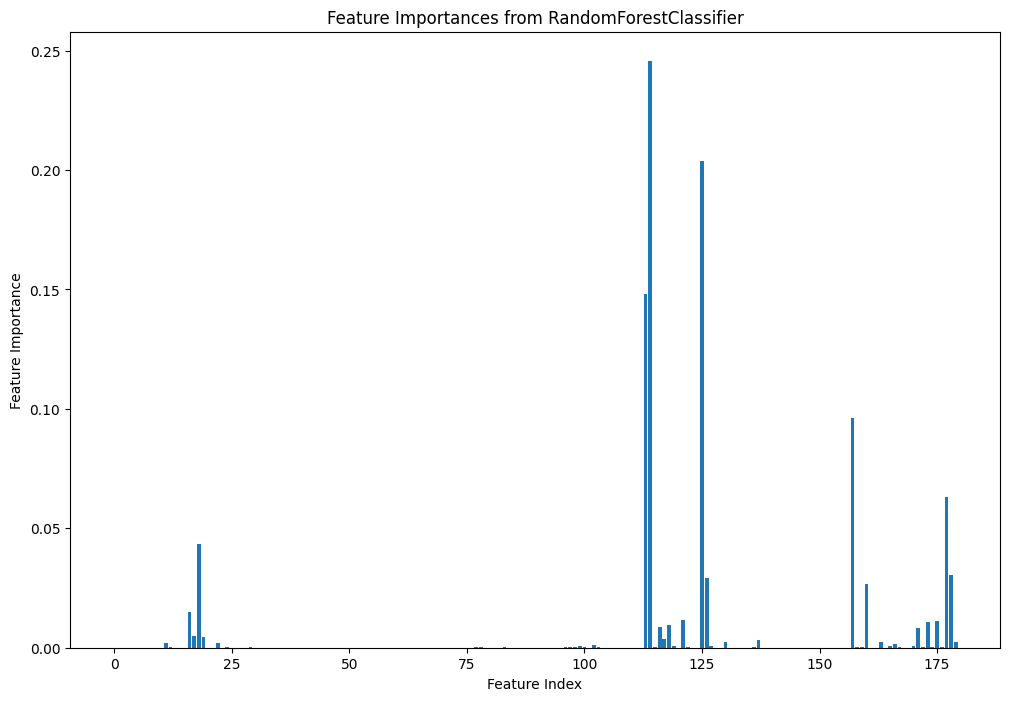

In [21]:
plt.figure(figsize=(12, 8))
plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature Index")
plt.ylabel("Feature Importance")
plt.title("Feature Importances from RandomForestClassifier")
plt.show()

We'll save the feature importances to a file so it can be used to filter our train and test sets in different configurations.

In [22]:
pkl.dump(
    feature_importances_df,
    open("../../../data/2021/processed/vbac/feature_importances_df.pkl", "wb"),
)